Prédiction du prix en fonction de la consomation prédite à J-1

In [25]:
#installation des librairies nécessaires 

!pip install scikit-learn
!pip install xgboost




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 179.5 kB/s eta 0:09:24
   ---------------------------------------- 0.5/101.7 MB 179.5 kB/s 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Bibliothèques 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBRegressor

print ("librairies importées")

librairies importées


Récupération du dataframe avec le données : date, day ahead prices, prévision J-1

Données : 52608 lignes | 2019-01-01 00:00:00 → 2024-12-31 00:00:00

Features utilisées (15) :
  - Prévision_conso_J1
  - Nucléaire
  - Eolien
  - Solaire
  - Hydraulique
  - Gaz
  - part_nucleaire
  - part_renouvelable
  - part_fossile
  - prix_lag_1h
  - prix_lag_24h
  - prix_lag_168h
  - prix_rolling_24h_mean
  - prix_rolling_24h_std
  - surplus_renouvelable

Train : 29760 obs | Test : 8784 obs
Train — moyenne : 56.1 | std : 39.1 | max : 276.1
Test  — moyenne : 58.0  | std : 40.7  | max : 284.2
Régression Linéaire       MAE= 15.07  RMSE=  20.59  R²=0.743  Std=20.50
Ridge                     MAE= 15.09  RMSE=  20.65  R²=0.742  Std=20.53
Lasso                     MAE= 15.00  RMSE=  20.74  R²=0.740  Std=20.70
Random Forest             MAE= 15.06  RMSE=  20.74  R²=0.740  Std=20.74
Gradient Boosting         MAE= 14.89  RMSE=  20.24  R²=0.752  Std=20.18

--- Classement des modèles ---
                        MAE    RMSE     R²  Std résidus
Gradient Boosting    14.891  20.238  0.752       2

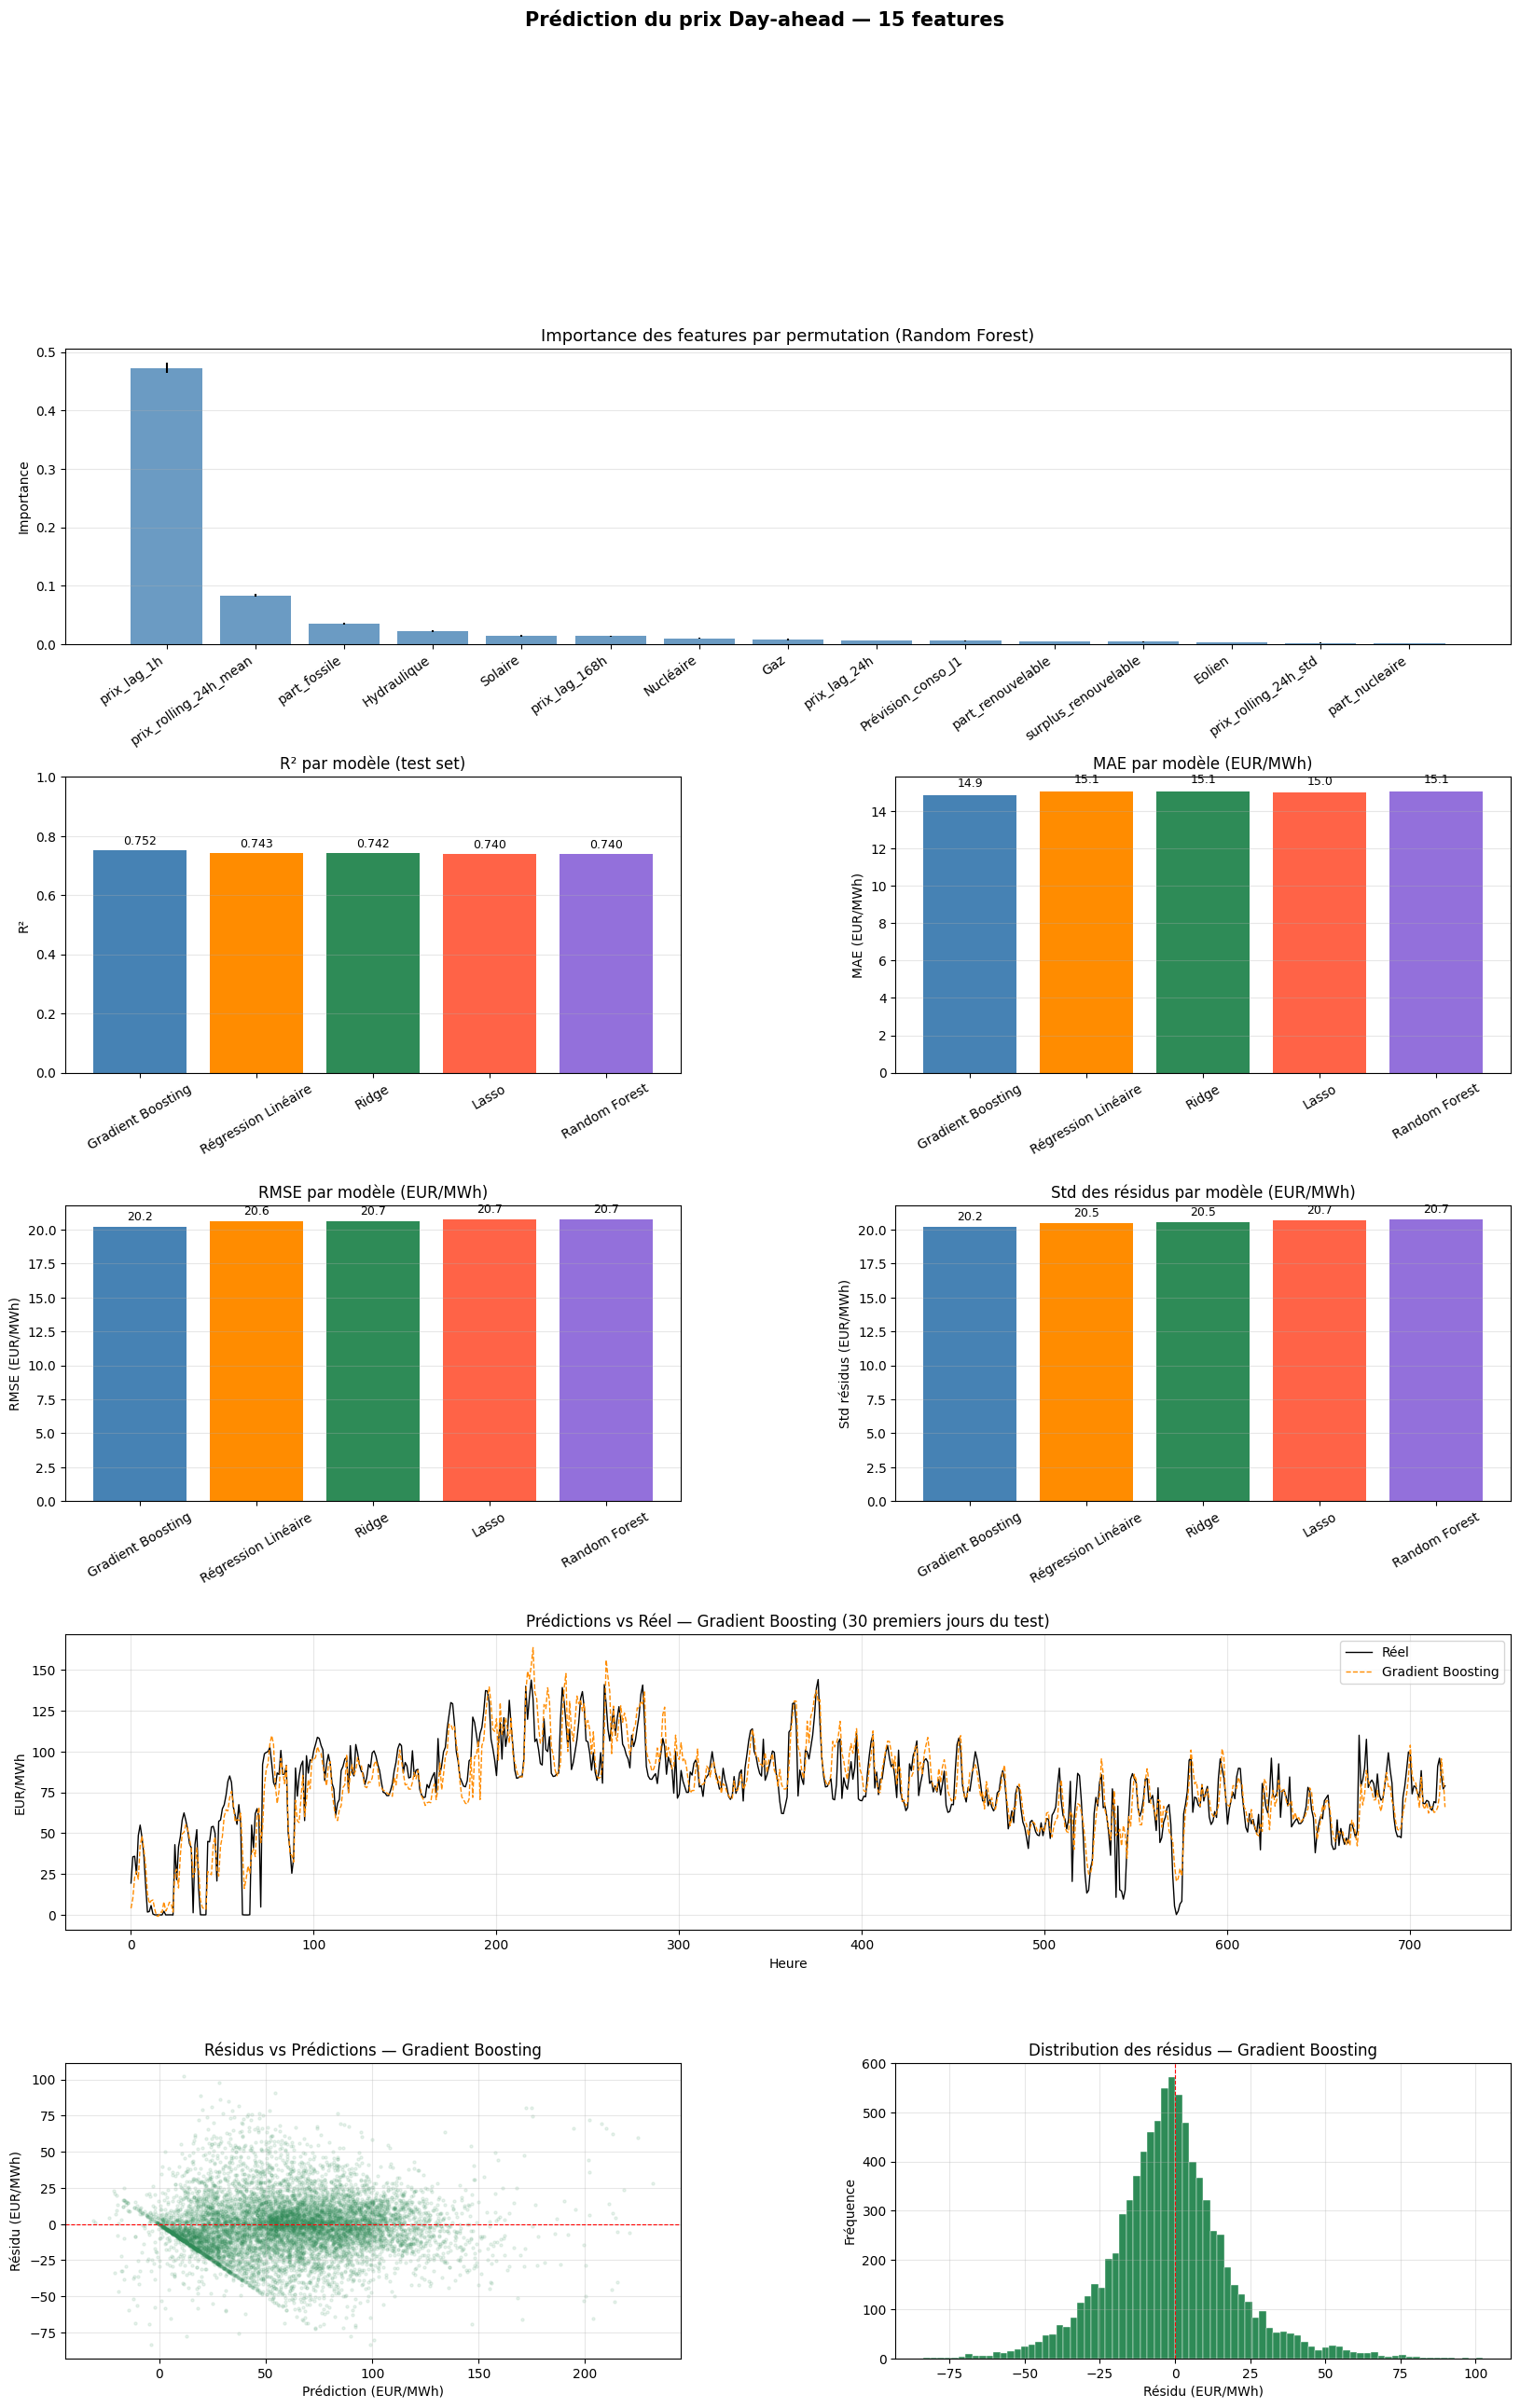

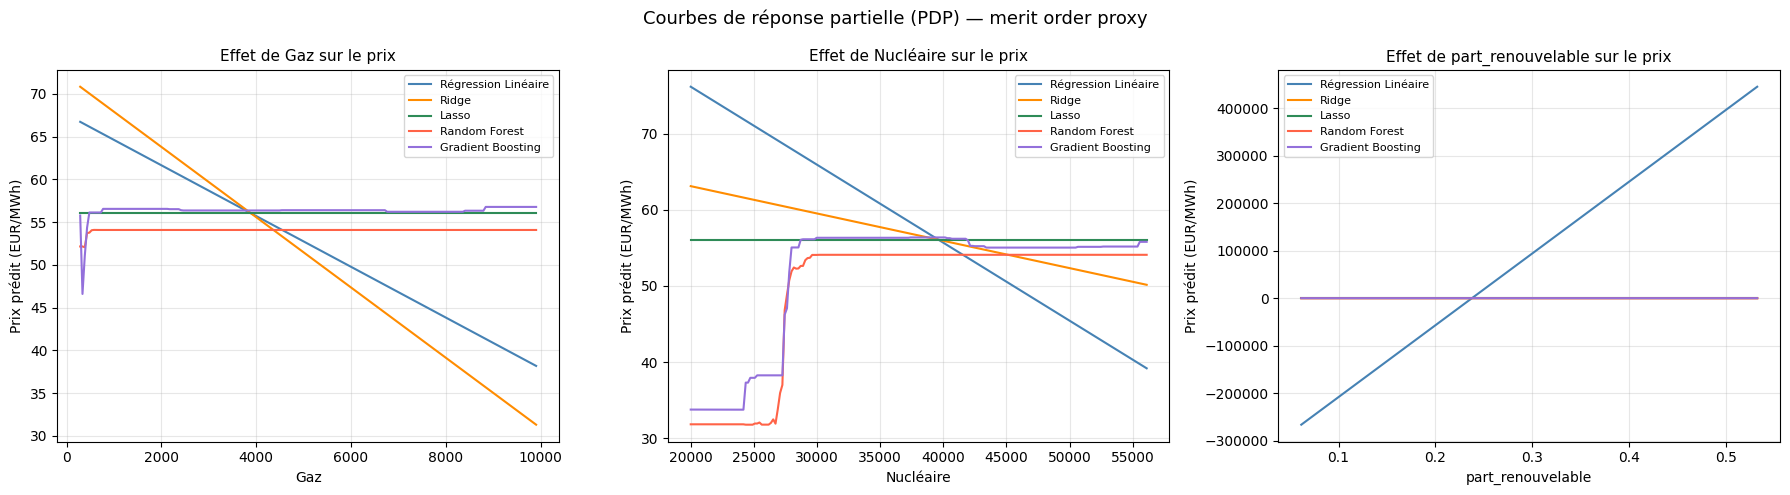

In [3]:
# =============================================================================
# 1. CHARGEMENT
# =============================================================================

df = pd.read_pickle("./Data/df_final_DayAheadPrices_PrevJ1.pkl")
df["Date"] = pd.to_datetime(df["Date"])
df["Prévision_conso_J1"] = pd.to_numeric(df["Prévision_conso_J1"], errors="coerce")
df["Day_ahead_price"]    = pd.to_numeric(df["Day_ahead_price"],    errors="coerce")

cols_prod = ["Nucléaire", "Eolien", "Solaire", "Hydraulique", "Gaz"]
for col in cols_prod:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Prévision_conso_J1", "Day_ahead_price"] + cols_prod).reset_index(drop=True)

print(f"Données : {df.shape[0]} lignes | {df['Date'].min()} → {df['Date'].max()}")

# =============================================================================
# 2. FEATURE ENGINEERING
# =============================================================================

df["part_nucleaire"]    = df["Nucléaire"] / (df[cols_prod].sum(axis=1) + 1)
df["part_renouvelable"] = (df["Eolien"] + df["Solaire"] + df["Hydraulique"]) / (df[cols_prod].sum(axis=1) + 1)
df["part_fossile"]      = df["Gaz"] / (df[cols_prod].sum(axis=1) + 1)

FEATURE_COLS = [
    "Prévision_conso_J1",
    "Nucléaire", "Eolien", "Solaire", "Hydraulique", "Gaz",
    "part_nucleaire", "part_renouvelable", "part_fossile",
]

df = df.sort_values("Date").reset_index(drop=True)

df["prix_lag_1h"]   = df["Day_ahead_price"].shift(1)
df["prix_lag_24h"]  = df["Day_ahead_price"].shift(24)
df["prix_lag_168h"] = df["Day_ahead_price"].shift(168)

df["prix_rolling_24h_mean"] = df["Day_ahead_price"].shift(1).rolling(24).mean()
df["prix_rolling_24h_std"]  = df["Day_ahead_price"].shift(1).rolling(24).std()

df = df.dropna().reset_index(drop=True)

FEATURE_COLS += ["prix_lag_1h", "prix_lag_24h", "prix_lag_168h",
                 "prix_rolling_24h_mean", "prix_rolling_24h_std"]

df["surplus_renouvelable"] = (
    df["Nucléaire"] + df["Eolien"] + df["Solaire"] + df["Hydraulique"]
) / (df["Prévision_conso_J1"] + 1)

FEATURE_COLS += ["surplus_renouvelable"]

TARGET_COL = "Day_ahead_price"

print(f"\nFeatures utilisées ({len(FEATURE_COLS)}) :")
for f in FEATURE_COLS:
    print(f"  - {f}")

# =============================================================================
# 3. SPLIT TEMPOREL — exclusion de la crise 2021-2022
# =============================================================================

mask_crise = (df["Date"] >= "2021-06-01") & (df["Date"] <= "2022-12-31")
mask_test  = (df["Date"] >= "2024-01-01")
mask_train = ~mask_crise & ~mask_test

df_train = df[mask_train].reset_index(drop=True)
df_test  = df[mask_test].reset_index(drop=True)

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain : {len(df_train)} obs | Test : {len(df_test)} obs")
print(f"Train — moyenne : {y_train.mean():.1f} | std : {y_train.std():.1f} | max : {y_train.max():.1f}")
print(f"Test  — moyenne : {y_test.mean():.1f}  | std : {y_test.std():.1f}  | max : {y_test.max():.1f}")

# =============================================================================
# 4. MODÈLES
# =============================================================================

models = {
    "Régression Linéaire": LinearRegression(),
    "Ridge":               Ridge(alpha=1.0),
    "Lasso":               Lasso(alpha=0.5),
    "Random Forest":       RandomForestRegressor(n_estimators=200, max_depth=8,
                                                  random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                      learning_rate=0.05, random_state=42),
}

results = {}
preds   = {}

for name, model in models.items():
    if name in ("Régression Linéaire", "Ridge", "Lasso"):
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae     = mean_absolute_error(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    r2      = r2_score(y_test, y_pred)
    std_res = np.std(y_test - y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2, "Std résidus": std_res}
    preds[name]   = y_pred

    print(f"{name:<25} MAE={mae:6.2f}  RMSE={rmse:7.2f}  R²={r2:.3f}  Std={std_res:.2f}")

# =============================================================================
# 5. TABLEAU RÉCAPITULATIF
# =============================================================================

df_results = pd.DataFrame(results).T.sort_values("R²", ascending=False)
print("\n--- Classement des modèles ---")
print(df_results.round(3).to_string())

# =============================================================================
# 6. VISUALISATIONS
# =============================================================================

fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)
colors = ["steelblue", "darkorange", "seagreen", "tomato", "mediumpurple"]

# 6a. Importance des features — Random Forest
ax0 = fig.add_subplot(gs[0, :])
rf_model = models["Random Forest"]
imp = permutation_importance(rf_model, X_test, y_test,
                              n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = imp.importances_mean.argsort()[::-1]
ax0.bar(range(len(FEATURE_COLS)),
        imp.importances_mean[sorted_idx],
        yerr=imp.importances_std[sorted_idx],
        color="steelblue", alpha=0.8)
ax0.set_xticks(range(len(FEATURE_COLS)))
ax0.set_xticklabels([FEATURE_COLS[i] for i in sorted_idx], rotation=35, ha="right")
ax0.set_title("Importance des features par permutation (Random Forest)", fontsize=13)
ax0.set_ylabel("Importance")
ax0.grid(axis="y", alpha=0.3)

# 6b. R² comparé
ax1 = fig.add_subplot(gs[1, 0])
bars = ax1.bar(df_results.index, df_results["R²"], color=colors[:len(df_results)])
ax1.set_title("R² par modèle (test set)", fontsize=12)
ax1.set_ylabel("R²")
ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, df_results["R²"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# 6c. MAE comparée
ax2 = fig.add_subplot(gs[1, 1])
bars2 = ax2.bar(df_results.index, df_results["MAE"], color=colors[:len(df_results)])
ax2.set_title("MAE par modèle (EUR/MWh)", fontsize=12)
ax2.set_ylabel("MAE (EUR/MWh)")
ax2.tick_params(axis="x", rotation=30)
for bar, val in zip(bars2, df_results["MAE"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# 6d. RMSE comparée
ax2b = fig.add_subplot(gs[2, 0])
bars3 = ax2b.bar(df_results.index, df_results["RMSE"], color=colors[:len(df_results)])
ax2b.set_title("RMSE par modèle (EUR/MWh)", fontsize=12)
ax2b.set_ylabel("RMSE (EUR/MWh)")
ax2b.tick_params(axis="x", rotation=30)
for bar, val in zip(bars3, df_results["RMSE"]):
    ax2b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax2b.grid(axis="y", alpha=0.3)

# 6e. Std des résidus comparée
ax2c = fig.add_subplot(gs[2, 1])
bars4 = ax2c.bar(df_results.index, df_results["Std résidus"], color=colors[:len(df_results)])
ax2c.set_title("Std des résidus par modèle (EUR/MWh)", fontsize=12)
ax2c.set_ylabel("Std résidus (EUR/MWh)")
ax2c.tick_params(axis="x", rotation=30)
for bar, val in zip(bars4, df_results["Std résidus"]):
    ax2c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax2c.grid(axis="y", alpha=0.3)

# 6f. Prédictions vs réel — meilleur modèle
best_model_name = df_results.index[0]
best_pred       = preds[best_model_name]
n_display       = 30 * 24

ax3 = fig.add_subplot(gs[3, :])
ax3.plot(range(n_display), y_test[:n_display],    label="Réel",          color="black",     linewidth=1)
ax3.plot(range(n_display), best_pred[:n_display], label=best_model_name, color="darkorange", linewidth=1, linestyle="--")
ax3.set_title(f"Prédictions vs Réel — {best_model_name} (30 premiers jours du test)", fontsize=12)
ax3.set_xlabel("Heure")
ax3.set_ylabel("EUR/MWh")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 6g. Résidus scatter
residuals = y_test - best_pred
ax4 = fig.add_subplot(gs[4, 0])
ax4.scatter(best_pred, residuals, alpha=0.1, s=5, color="seagreen")
ax4.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax4.set_title(f"Résidus vs Prédictions — {best_model_name}", fontsize=12)
ax4.set_xlabel("Prédiction (EUR/MWh)")
ax4.set_ylabel("Résidu (EUR/MWh)")
ax4.grid(True, alpha=0.3)

# 6h. Distribution des résidus
ax5 = fig.add_subplot(gs[4, 1])
ax5.hist(residuals, bins=80, color="seagreen", edgecolor="white", linewidth=0.3)
ax5.axvline(0, color="red", linewidth=0.8, linestyle="--")
ax5.set_title(f"Distribution des résidus — {best_model_name}", fontsize=12)
ax5.set_xlabel("Résidu (EUR/MWh)")
ax5.set_ylabel("Fréquence")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Prédiction du prix Day-ahead — {len(FEATURE_COLS)} features",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

# =============================================================================
# 7. COURBES DE RÉPONSE PARTIELLE
# =============================================================================

fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ["Gaz", "Nucléaire", "part_renouvelable"]):
    feat_idx   = FEATURE_COLS.index(feature)
    feat_range = np.linspace(X_train[:, feat_idx].min(),
                              X_train[:, feat_idx].max(), 200)
    X_pdp = np.tile(X_train.mean(axis=0), (200, 1))
    X_pdp[:, feat_idx] = feat_range

    for (name, model), color in zip(models.items(), colors):
        if name in ("Régression Linéaire", "Ridge", "Lasso"):
            X_pdp_sc = scaler.transform(X_pdp)
            y_pdp    = model.predict(X_pdp_sc)
        else:
            y_pdp    = model.predict(X_pdp)
        ax.plot(feat_range, y_pdp, label=name, linewidth=1.5, color=color)

    ax.set_title(f"Effet de {feature} sur le prix", fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel("Prix prédit (EUR/MWh)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Courbes de réponse partielle (PDP) — merit order proxy", fontsize=13)
plt.tight_layout()
plt.show()